<a href="https://colab.research.google.com/github/avineshprabhakaran/-End-to-End-BPM-Prediction/blob/main/text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [2]:
!pip install -U transformers


In [3]:
from datasets import load_dataset

imdb = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
print(imdb)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


### Accessing the 'train' split

In [5]:
train_dataset = imdb['train']
print(train_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


### Accessing the 'test' split

In [6]:
test_dataset = imdb['test']
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


In [7]:
import pandas as pd

print("Pandas imported successfully.")

Pandas imported successfully.


In [8]:
train_df = train_dataset.to_pandas()
train_df.to_csv('train_dataset.csv', index=False)
print("train_dataset successfully converted to 'train_dataset.csv'.")

train_dataset successfully converted to 'train_dataset.csv'.


In [9]:
train_df

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
...,...,...
24995,A hit at the time but now better categorised a...,1
24996,I love this movie like no other. Another time ...,1
24997,This film and it's sequel Barry Mckenzie holds...,1
24998,'The Adventures Of Barry McKenzie' started lif...,1


In [10]:
test_df = test_dataset.to_pandas()
test_df.to_csv('test_dataset.csv', index=False)
print("test_dataset successfully converted to 'test_dataset.csv'.")

test_dataset successfully converted to 'test_dataset.csv'.


In [11]:
test_df

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0
...,...,...
24995,Just got around to seeing Monster Man yesterda...,1
24996,I got this as part of a competition prize. I w...,1
24997,I got Monster Man in a box set of three films ...,1
24998,"Five minutes in, i started to feel how naff th...",1


In [12]:
#from transformers import AutoTokenizer

#tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")


In [13]:
model_checkpoint = "distilbert/distilbert-base-uncased"


In [14]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )


train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("Tokenization completed successfully ✅")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Tokenization completed successfully ✅


In [15]:
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")


In [16]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print("✅ Format set successfully")


✅ Format set successfully


In [17]:
from transformers import AutoModelForSequenceClassification


In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
print(model.config.num_labels)
print(train_dataset.column_names)


2
['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [20]:
import evaluate
accuracy = evaluate.load("accuracy")


In [21]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return accuracy.compute(predictions=preds, references=labels)


In [22]:
import transformers
print(transformers.__version__)


5.0.0


In [23]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./imdb_distilbert",
    eval_strategy="epoch",          # ✅ renamed in v5
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)


In [24]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,0.257054,0.248713,0.901400
2,0.164882,0.270275,0.913600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3126, training_loss=0.22710053766681382, metrics={'train_runtime': 1361.7512, 'train_samples_per_second': 36.717, 'train_steps_per_second': 2.296, 'total_flos': 3311684966400000.0, 'train_loss': 0.22710053766681382, 'epoch': 2.0})

In [25]:
results = trainer.evaluate()
print(results)


{'eval_loss': 0.2702745199203491, 'eval_accuracy': 0.9136, 'eval_runtime': 159.1169, 'eval_samples_per_second': 157.117, 'eval_steps_per_second': 9.823, 'epoch': 2.0}


In [29]:
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
labels = predictions.label_ids

import numpy as np
y_pred = np.argmax(logits, axis=1)
y_true = labels


In [30]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print(cm)


[[11304  1196]
 [  964 11536]]


In [31]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"]
))


              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91     12500
    Positive       0.91      0.92      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



In [34]:
predictions = trainer.predict(test_dataset)

import numpy as np
from scipy.special import softmax

logits = predictions.predictions
y_true = predictions.label_ids

y_probs = softmax(logits, axis=1)[:, 1]  # probability of Positive class


In [35]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_true, y_probs)
print("ROC–AUC Score:", roc_auc)


ROC–AUC Score: 0.972278304


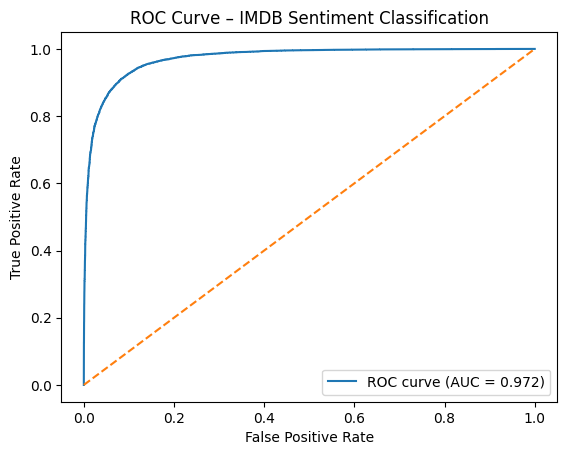

In [36]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – IMDB Sentiment Classification")
plt.legend()
plt.show()
